# Preprocessing
## 1 Label Encoder vs Ordinal Encoder
## 2 One Hot Encoder (drop first)
## 3 PCA (giảm chiều dữ liệu)
## 4 Linear Regression

# 1. Label Encoder

In [137]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS
from statsmodels.formula.api import ols
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [136]:
!pip install seaborn

In [89]:
data1 = pd.DataFrame([
    ['Male'],
    ['Male'],
    ['Female'],
    ['Male'],
], columns=['Gender'])

data1

,Gender
0,Male
1,Male
2,Female
3,Male


In [90]:
encoder = LabelEncoder()
encoder.fit_transform(data1['Gender'])

array([1, 1, 0, 1])

In [91]:
data2 = pd.DataFrame([
    ['red'],
    ['blue'],
    ['red'],
    ['orange'],
    ['cyan'],
    ['blue'],
], columns=['Color'])

data2

,Color
0,red
1,blue
2,red
3,orange
4,cyan
5,blue


In [92]:
encoder = LabelEncoder()
encoder.fit_transform(data2['Color'])

array([3, 0, 3, 2, 1, 0])

In [93]:
data3 = pd.DataFrame([
    ['Male', 'PhD'],
    ['Female', 'Master'],
    ['Male', 'Master'],
    ['Male', 'High school'],
], columns=['Gender', 'Education Level'])

data3

,Gender,Education Level
0,Male,PhD
1,Female,Master
2,Male,Master
3,Male,High school


In [94]:
encoder = OrdinalEncoder()
encoder.fit_transform(data3[['Gender', 'Education Level']])

array([[1., 2.],
       [0., 1.],
       [1., 1.],
       [1., 0.]])

# One Hot Encoder

In [95]:
data4 = pd.DataFrame([
    ['Male'],
    ['Female'],
    ['Male'],
    ['Other'],
    ['Male'],
], columns=['Gender'])
data4

,Gender
0,Male
1,Female
2,Male
3,Other
4,Male


In [96]:
data4['Gender'].shape, data4[['Gender']].shape

((5,), (5, 1))

In [97]:
encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoder.fit_transform(data4[['Gender']])

array([[0, 1, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 1, 0]])

In [98]:
data5 = pd.DataFrame([
    ['Male'],
    ['Female'],
    ['Male'],
    ['Other'],
    ['Male'],
], columns=['Gender'])


In [99]:
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
encoder.fit_transform(data5)

array([[1, 0],
       [0, 0],
       [1, 0],
       [0, 1],
       [1, 0]])

# PCA (unsupper)

In [100]:
data6 = pd.read_csv('data/Salary_Data.csv')
data6.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0


## PCA
### B1: tính trung bình theo từng cột $\bar{X}$
### B2: tính $\hat{X} = X - \bar{X}$
### B3: tính ma trận hiệp phương sai (ma trận hệ số tương quan)$\frac{1}{n-1} * \hat{X}^T * \hat{X}$
### B4: giá trị riêng (đại số tuyến tính)
### B5: sắp xếp giảm dần theo giá trị riêng => tính vector riêng (page rank (SEO), PCA, hệ hỗ trợ ra quyết định (tính sấp sỉ), GIS (giảm chiều ~ SVD))
### B6: chọn ra k thành phần

In [101]:
X = data6[['Age', 'Years of Experience']]
X.shape

(6704, 2)

In [102]:
X.isna().sum()

Age                    2
Years of Experience    3
dtype: int64

In [103]:
X.dropna(inplace=True)

C:\Users\My Computer\AppData\Local\Temp\ipykernel_33928\490656300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.dropna(inplace=True)


In [28]:
#Xbar = np.mean(X, axits=0)
Xbar = X.mean()
Xbar

Age                    33.621997
Years of Experience     8.094687
dtype: float64

In [104]:
Xhat = X - Xbar
Xhat.head()

,Age,Years of Experience
0,-1.621997,-3.094687
1,-5.621997,-5.094687
2,11.378003,6.905313
3,2.378003,-1.094687
4,18.378003,11.905313


In [105]:
X.shape[0]

6701

In [106]:
sigma = (1 / (X.shape[0])) * Xhat.T @ Xhat
sigma

,Age,Years of Experience
Age,57.973962,43.254192
Years of Experience,43.254192,36.706040


In [107]:
eigenvalue, eigenvectors = np.linalg.eig(sigma)
eigenvalue

array([91.88218611,  2.79781517])

In [108]:
eigenvectors

array([[ 0.78700035, -0.61695255],
       [ 0.61695255,  0.78700035]])

In [109]:
# giảm xuống 1 chiều
Xhat @ eigenvectors[:, 0]

0       -3.185787
1       -7.567694
2       13.214743
3        1.196119
4       21.808508
          ...    
6699    19.447507
6700    -4.419692
6701    -5.376740
6702    13.384791
6703   -10.375600
Length: 6701, dtype: float64

In [110]:
# giữ nguyên số chiều 
Xhat @ eigenvectors

,0,1
0,-3.185787,-1.434825
1,-7.567694,-0.541016
2,13.214743,-1.585205
3,1.196119,-2.328635
4,21.808508,-1.968871
...,...,...
6699,19.447507,-0.118013
6700,-4.419692,-3.008826
6701,-5.376740,-0.987920
6702,13.384791,-2.989158


In [111]:
pca = PCA(n_components=2)
pca.fit(X)
pca.components_, pca.explained_variance_

(array([[ 0.78700035,  0.61695255],
        [-0.61695255,  0.78700035]]),
 array([91.89589987,  2.79823275]))

In [112]:
pca.transform(X)

array([[ -3.18578725,  -1.43482502],
       [ -7.56769374,  -0.5410155 ],
       [ 13.2147428 ,  -1.58520471],
       ...,
       [ -5.3767405 ,  -0.98792026],
       [ 13.3847906 ,  -2.98915761],
       [-10.37559955,  -0.8811111 ]], shape=(6701, 2))

In [113]:
pca= PCA(n_components=1)
pca.fit_transform(X)

array([[ -3.18578725],
       [ -7.56769374],
       [ 13.2147428 ],
       ...,
       [ -5.3767405 ],
       [ 13.3847906 ],
       [-10.37559955]], shape=(6701, 1))

## Chạy mô hình hồi quy tuyến tính (Linar Regression)

In [114]:
df = pd.read_csv('data/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Kiểm tra dữ liệu null

In [115]:
df.isna().sum(), df.shape

(Age                    2
 Gender                 2
 Education Level        3
 Job Title              2
 Years of Experience    3
 Salary                 5
 dtype: int64,
 (6704, 6))

In [116]:
df[df['Age'].isna() |df['Gender'].isna() |df['Education Level'].isna() |df['Job Title'].isna() |df['Years of Experience'].isna() |df['Salary'].isna()].shape[0] * 100 / df.shape[0]

0.08949880668257756

## Xóa dữ liệu

In [117]:
df.dropna(inplace=True)

In [118]:
df.shape

(6698, 6)

##  Áp dụng One Hot Encoder (drop first)

In [119]:
df['Gender'].value_counts()

Gender
Male      3671
Female    3013
Other       14
Name: count, dtype: int64

In [120]:
# Tiền xử lý lỗi chính tả
df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2265
Master's Degree      1572
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [121]:
df['Job Title'].value_counts()

Job Title
Software Engineer                     518
Data Scientist                        453
Software Engineer Manager             376
Data Analyst                          363
Senior Project Engineer               318
                                     ... 
Junior Research Scientist               1
Senior Product Development Manager      1
Junior Social Media Specialist          1
Senior Software Architect               1
Social Media Man                        1
Name: count, Length: 191, dtype: int64

## do cột **Job title** nhiều giá trị => xóa cột **Job Title**

In [122]:
df.drop(columns='Job Title', inplace=True)

## Xử lý lỗi chính tả trên biến **Education Level**

In [123]:
df['Education Level'].value_counts()

Education Level
Bachelor's Degree    2265
Master's Degree      1572
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

In [124]:
# Naive
def clean_education_level_naive(text):
    if text == "phD":
        return "PhD"
    if text == "Bachelor's":
        return "Bachelor's Degree"
    if text == "Master's":
        return "Master's Degree"
    return text
df['Education Level'].map(clean_education_level_naive).value_counts()

Education Level
Bachelor's Degree    3021
Master's Degree      1860
PhD                  1369
High School           448
Name: count, dtype: int64

In [125]:
# dictionary (hash table (cấu trúc dữ liệu))
def clean_education_level(text):
    dic = {
        'phD': 'PhD',
        "Bachelor's": "Bachelor's Degree",
        "Master's": "Master's Degree"
    }
    if text in dic:
        return dic[text]
    return text
df['Education Level'].map(clean_education_level).value_counts()

Education Level
Bachelor's Degree    3021
Master's Degree      1860
PhD                  1369
High School           448
Name: count, dtype: int64

In [126]:
df['Education Level'] = df['Education Level'].map(clean_education_level)

In [127]:
df.head()

,Age,Gender,Education Level,Years of Experience,Salary
0,32.0,Male,Bachelor's Degree,5.0,90000.0
1,28.0,Female,Master's Degree,3.0,65000.0
2,45.0,Male,PhD,15.0,150000.0
3,36.0,Female,Bachelor's Degree,7.0,60000.0
4,52.0,Male,Master's Degree,20.0,200000.0


## Biến đổi One Hot Encoder (drop first) trên 2 biến Gender và Education Level

# Tại sao 2 cột Gender và Education Level lại phải dùng One Hot Encoder (drop first)

In [128]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
#encoder.fit_transform(df[['Gender','Education Level']])

In [129]:
cols_cat = ['Gender', 'Education Level']
cols = []
for col in cols_cat:
    # print(sorted(df[col].unique())[1:])
    for name in sorted(df[col].unique())[1:]:
        cols.append(f'{col}_{name}')
df[cols] = encoder.fit_transform(df[['Gender', 'Education Level']])

In [131]:
df.head()

,Age,Gender,Education Level,Years of Experience,Salary,Gender_Male,Gender_Other,Education Level_High School,Education Level_Master's Degree,Education Level_PhD
0,32.0,Male,Bachelor's Degree,5.0,90000.0,1.0,0.0,0.0,0.0,0.0
1,28.0,Female,Master's Degree,3.0,65000.0,0.0,0.0,0.0,1.0,0.0
2,45.0,Male,PhD,15.0,150000.0,1.0,0.0,0.0,0.0,1.0
3,36.0,Female,Bachelor's Degree,7.0,60000.0,0.0,0.0,0.0,0.0,0.0
4,52.0,Male,Master's Degree,20.0,200000.0,1.0,0.0,0.0,1.0,0.0


In [150]:
X = df[['Age', 'Years of Experience', 'Gender_Male', 'Gender_Other','Education Level_High School', "Education Level_Master's Degree",'Education Level_PhD']]
y = df['Salary']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y)
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.716862726289264, 0.7181768846349081)

## tính correlation
### $$corr(x,y) =\frac{\sum (x_i - \bar{x}) (y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \times \sum (y_i - \bar{y})^2}}$$

#### Lưu ý: trong hồi qui tuyến tính
#### (X (Age, Salary) biến độc lập)
#### (y biến phụ thuộc)

In [ ]:
df[['Age', 'Years of Experience', 'Salary']].corr()

,Age,Years of Experience,Salary
Age,1.000000,0.937725,0.728061
Years of Experience,0.937725,1.000000,0.808968
Salary,0.728061,0.808968,1.000000


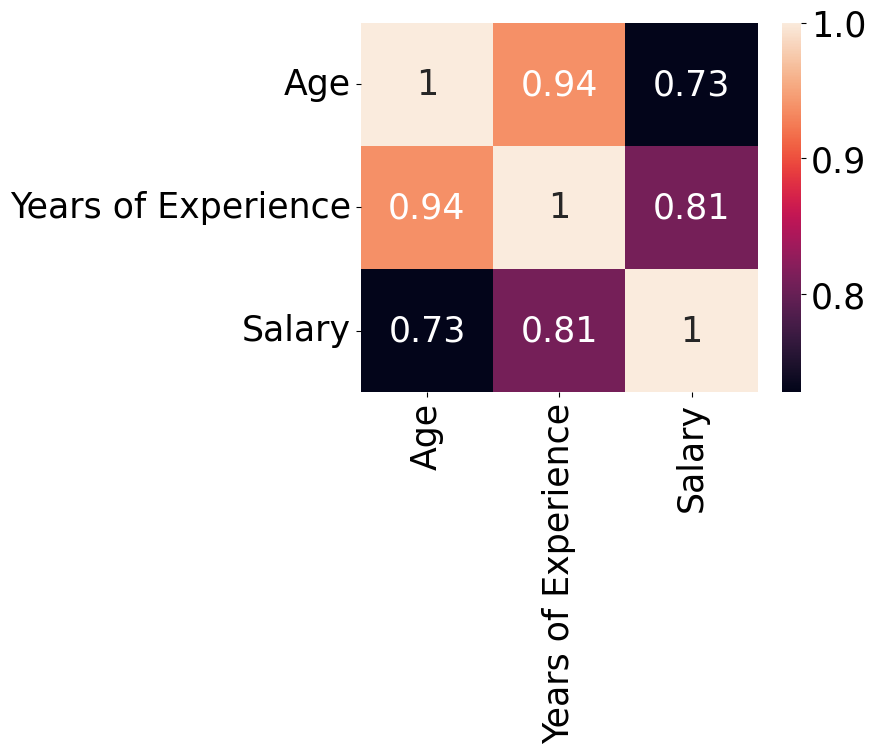

In [138]:
plt.rcParams['font.size'] = 25
sns.heatmap(df[['Age', 'Years of Experience', 'Salary']].corr(), annot=True)
plt.show()

#### Tuổi càng cao -> số năm kinh nghiệm càng nhiều (0.94)
#### Tuổi càng cao -> mức lương cao (0.73)
#### Số năm kinh nghiệm càng nhiều -> mức lương sẽ cao

In [140]:
X = df[['Age', 'Years of Experience', 'Gender_Male', 'Gender_Other','Education Level_High School', "Education Level_Master's Degree",'Education Level_PhD']]
y = df['Salary']

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y)
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.7135014352992048, 0.7279778941887822)

## coef(hệ số hồi quy)

In [145]:
lg.coef_

array([ -2048.03382212,   8052.58732963,   5863.63965025,   2279.2290227 ,
       -35840.78329447,  12162.71311095,  23741.03858453])

In [146]:
df_coef = pd.DataFrame({
    'features': X.columns,
    'coef': lg.coef_,
    'coefAbs': np.abs(lg.coef_)
}).sort_values(by='coefAbs')
df_coef

,features,coef,coefAbs
0,Age,-2048.033822,2048.033822
3,Gender_Other,2279.229023,2279.229023
2,Gender_Male,5863.639650,5863.639650
1,Years of Experience,8052.587330,8052.587330
5,Education Level_Master's Degree,12162.713111,12162.713111
6,Education Level_PhD,23741.038585,23741.038585
4,Education Level_High School,-35840.783294,35840.783294


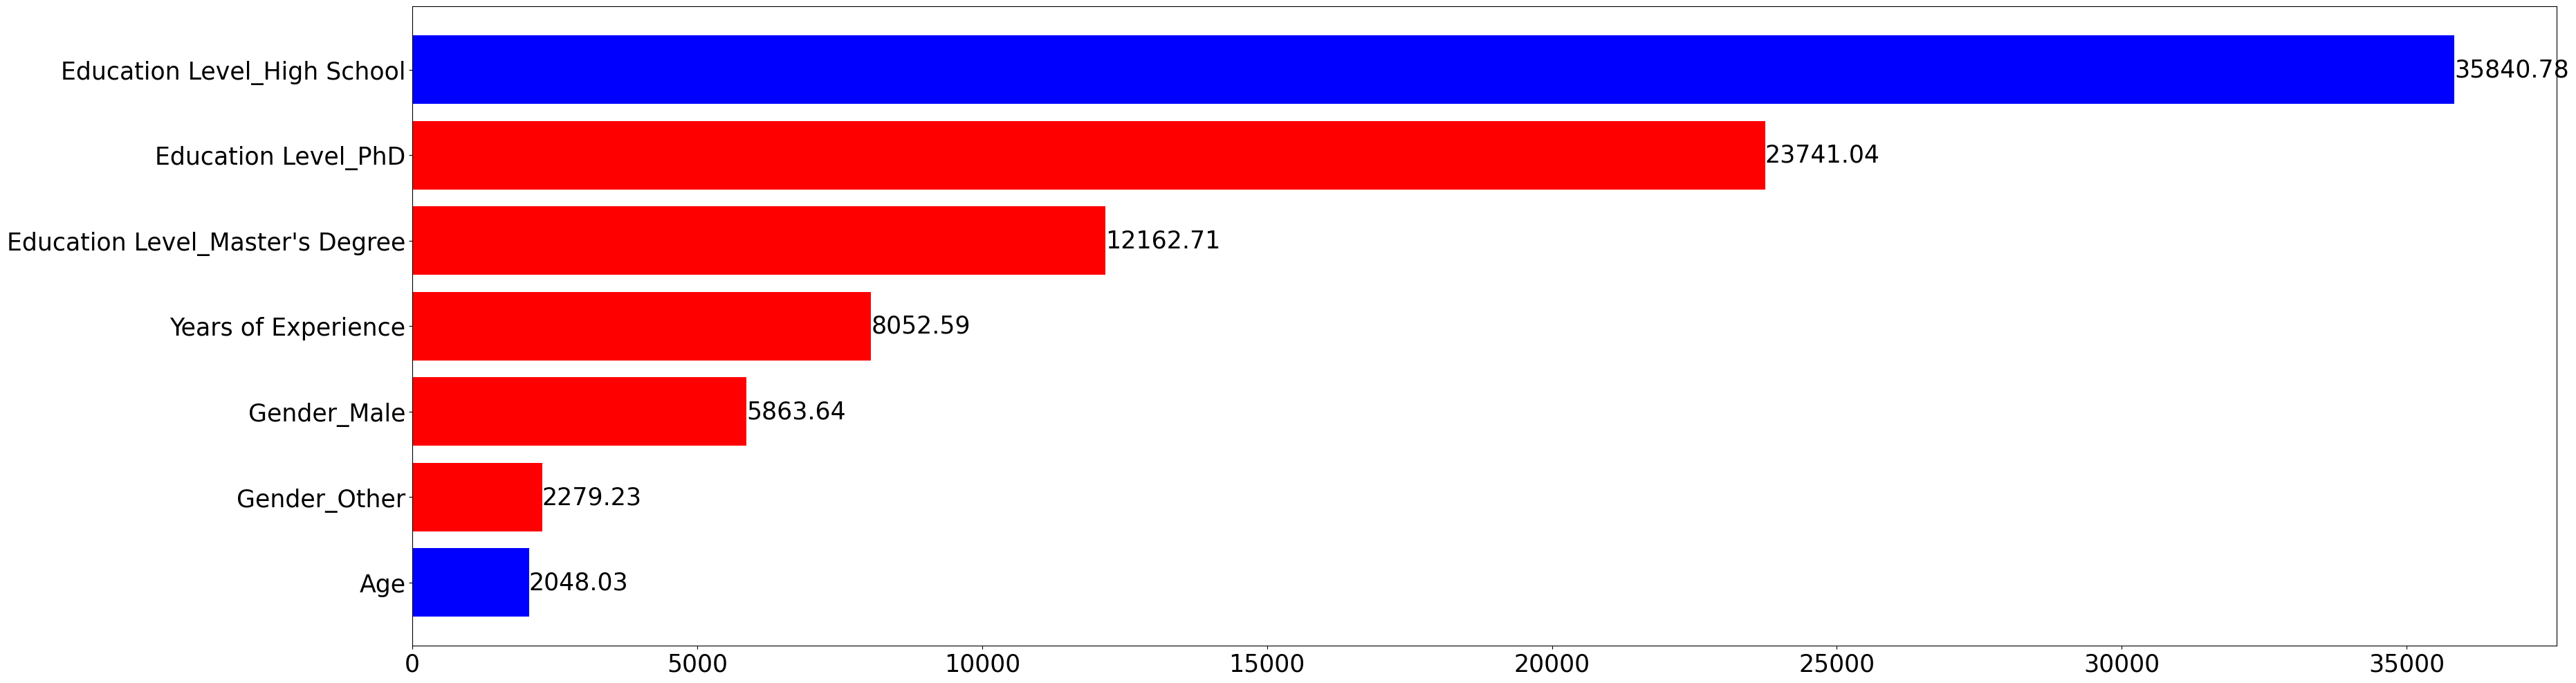

In [149]:
colors = ['red' if v > 0 else 'blue' for v in df_coef['coef']]
fig, ax = plt.subplots(figsize=(40, 12))
bars = ax.barh(y=df_coef['features'], width=df_coef['coefAbs'], color=colors
)
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')
plt.show()

#### Xóa 1 trong 2 biến (Age vs Years of Experience) 
#### (giữ lại biến Years of Experience do 2 biến Age vs Years of Experience có tương quan rất cao (0.94))
#### trường hợp 2 dùng PCA

## Xét TH1: Xóa biến Age

In [152]:
X = df[['Years of Experience', 'Gender_Male', 'Gender_Other',
        'Education Level_High School', "Education Level_Master's Degree",
        'Education Level_PhD']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y)
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.7054010777601664, 0.713113205968994)

## TH2: dùng PCA
### Chỉ sử dụng 1 component

In [165]:
pca = PCA(n_components=1)
df[['AgeYearsofExperience']] = pca.fit_transform(df[['Age', 'Years of Experience']])

In [159]:
X = df[['AgeYearsofExperience', 'Gender_Male', 'Gender_Other', 'Education Level_High School', "Education Level_Master's Degree", 'Education Level_PhD']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y)
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.6672690210683685, 0.6437540498186267)

### Sử dụng 2 components

In [162]:
pca = PCA(n_components=2)
df[['c1', 'c2']] = pca.fit_transform(df[['Age', 'Years of Experience']])

In [163]:
df[['c1', 'c2', 'Salary']].corr()

,c1,c2,Salary
c1,1.000000e+00,-3.089422e-16,0.770582
c2,-3.089422e-16,1.000000e+00,0.261450
Salary,7.705823e-01,2.614501e-01,1.000000


In [164]:
X = df[['c1', 'c2', 'Gender_Male', 'Gender_Other', 'Education Level_High School', "Education Level_Master's Degree", 'Education Level_PhD']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=2026
)
lg = LinearRegression()
lg.fit(X_train, y_train)
lg.score(X_train, y_train), lg.score(X_test, y_test)

(0.7155878028731927, 0.7217209212033051)